### Verify performance: SR-derived formula vs baselines

Compares the published SR-derived formula against the three baseline models (ESWF, WSA-ENLIL, 27-day persistence) on the Oct-Dec test months, ICME periods excluded, using [`src/evaluation/model_comparison.py`](../src/evaluation/model_comparison.py):
1. Entire-period metrics
2. Yearly metrics
3. Per-solar-cycle-phase metrics (MAE/RMSE/CC/DTW) -- **this table is what goes into the paper**
4. A supplementary heatmap view of performance by OMNI speed range (not published; see [`figures/figure3_performance_by_speed_range.png`](../figures/figure3_performance_by_speed_range.png) for the published version)

In [1]:
import os, sys
sys.path.append(os.path.abspath("../src"))

import matplotlib.pyplot as plt

from evaluation.model_comparison import (
    build_comparison_df, evaluate_metrics, compute_binned_stats, SOLAR_CYCLE_PHASES,
)
from viz.performance import plot_binned_performance_heatmap

df, cr_df = build_comparison_df(data_dir="../data")
print(f"{len(df):,} rows, {df['datetime'].min()} to {df['datetime'].max()}")

131,496 rows, 2010-01-01 00:00:00 to 2024-12-31 23:00:00


---

#### 1. Entire-period metrics

In [2]:
evaluate_metrics(df, group_by=None)

,MAE,RMSE,CC,N,model
0,60.02,78.37,0.549,24789,best_sr
1,82.26,108.94,0.379,24789,eswf2
2,70.86,96.16,0.459,24789,speed_p27
3,91.25,120.31,0.363,24789,wsa_enlil


---

#### 2. Yearly metrics

In [3]:
evaluate_metrics(df, group_by="year")

,MAE,RMSE,CC,N,model,year
0,67.08,85.76,0.408,1877,best_sr,2010
1,82.38,113.64,0.291,1877,eswf2,2010
2,81.75,105.63,0.321,1877,speed_p27,2010
3,80.13,112.61,0.354,1877,wsa_enlil,2010
4,51.00,65.88,0.043,1143,best_sr,2011
5,74.94,102.39,0.155,1143,eswf2,2011
6,57.41,81.02,0.018,1143,speed_p27,2011
7,76.45,91.49,0.029,1143,wsa_enlil,2011
8,64.76,76.95,0.338,1210,best_sr,2012
9,71.50,95.44,0.166,1210,eswf2,2012


---

#### 3. Per-solar-cycle-phase metrics (paper table)

Includes Dynamic Time Warping distance (Samara et al. 2022) alongside MAE/RMSE/CC -- DTW captures whether the *shape*/timing of predicted enhancements matches observations, not just pointwise error.

In [4]:
phase_metrics_df = evaluate_metrics(
    df, group_by="phase", groups=SOLAR_CYCLE_PHASES, include_dtw=True, dtw_window=48,
)
phase_metrics_df

,MAE,RMSE,CC,N,DTW_norm,DTW_raw,model,phase
0,54.66,70.48,0.716,7340,0.004134,30.34,best_sr,Declining
1,76.64,102.14,0.523,7340,0.005904,43.34,eswf2,Declining
2,66.60,88.63,0.624,7340,0.005209,38.24,speed_p27,Declining
3,86.10,114.17,0.470,7340,0.006641,48.75,wsa_enlil,Declining
4,59.53,77.70,0.344,4821,0.009348,45.07,best_sr,Maximum
5,79.23,101.33,0.177,4821,0.010784,51.99,eswf2,Maximum
6,63.43,87.78,0.324,4821,0.009981,48.12,speed_p27,Maximum
7,91.34,112.76,0.303,4821,0.012391,59.74,wsa_enlil,Maximum
8,48.61,61.45,0.617,3713,0.007618,28.29,best_sr,Minimum
9,81.10,107.68,0.414,3713,0.010621,39.44,eswf2,Minimum


---

#### 4. Performance by OMNI speed range (supplementary heatmap view)

Same binned statistics as Figure 3, with an added heatmap row for a quicker at-a-glance read. Exploratory only -- not saved as a separate file, shown inline here.

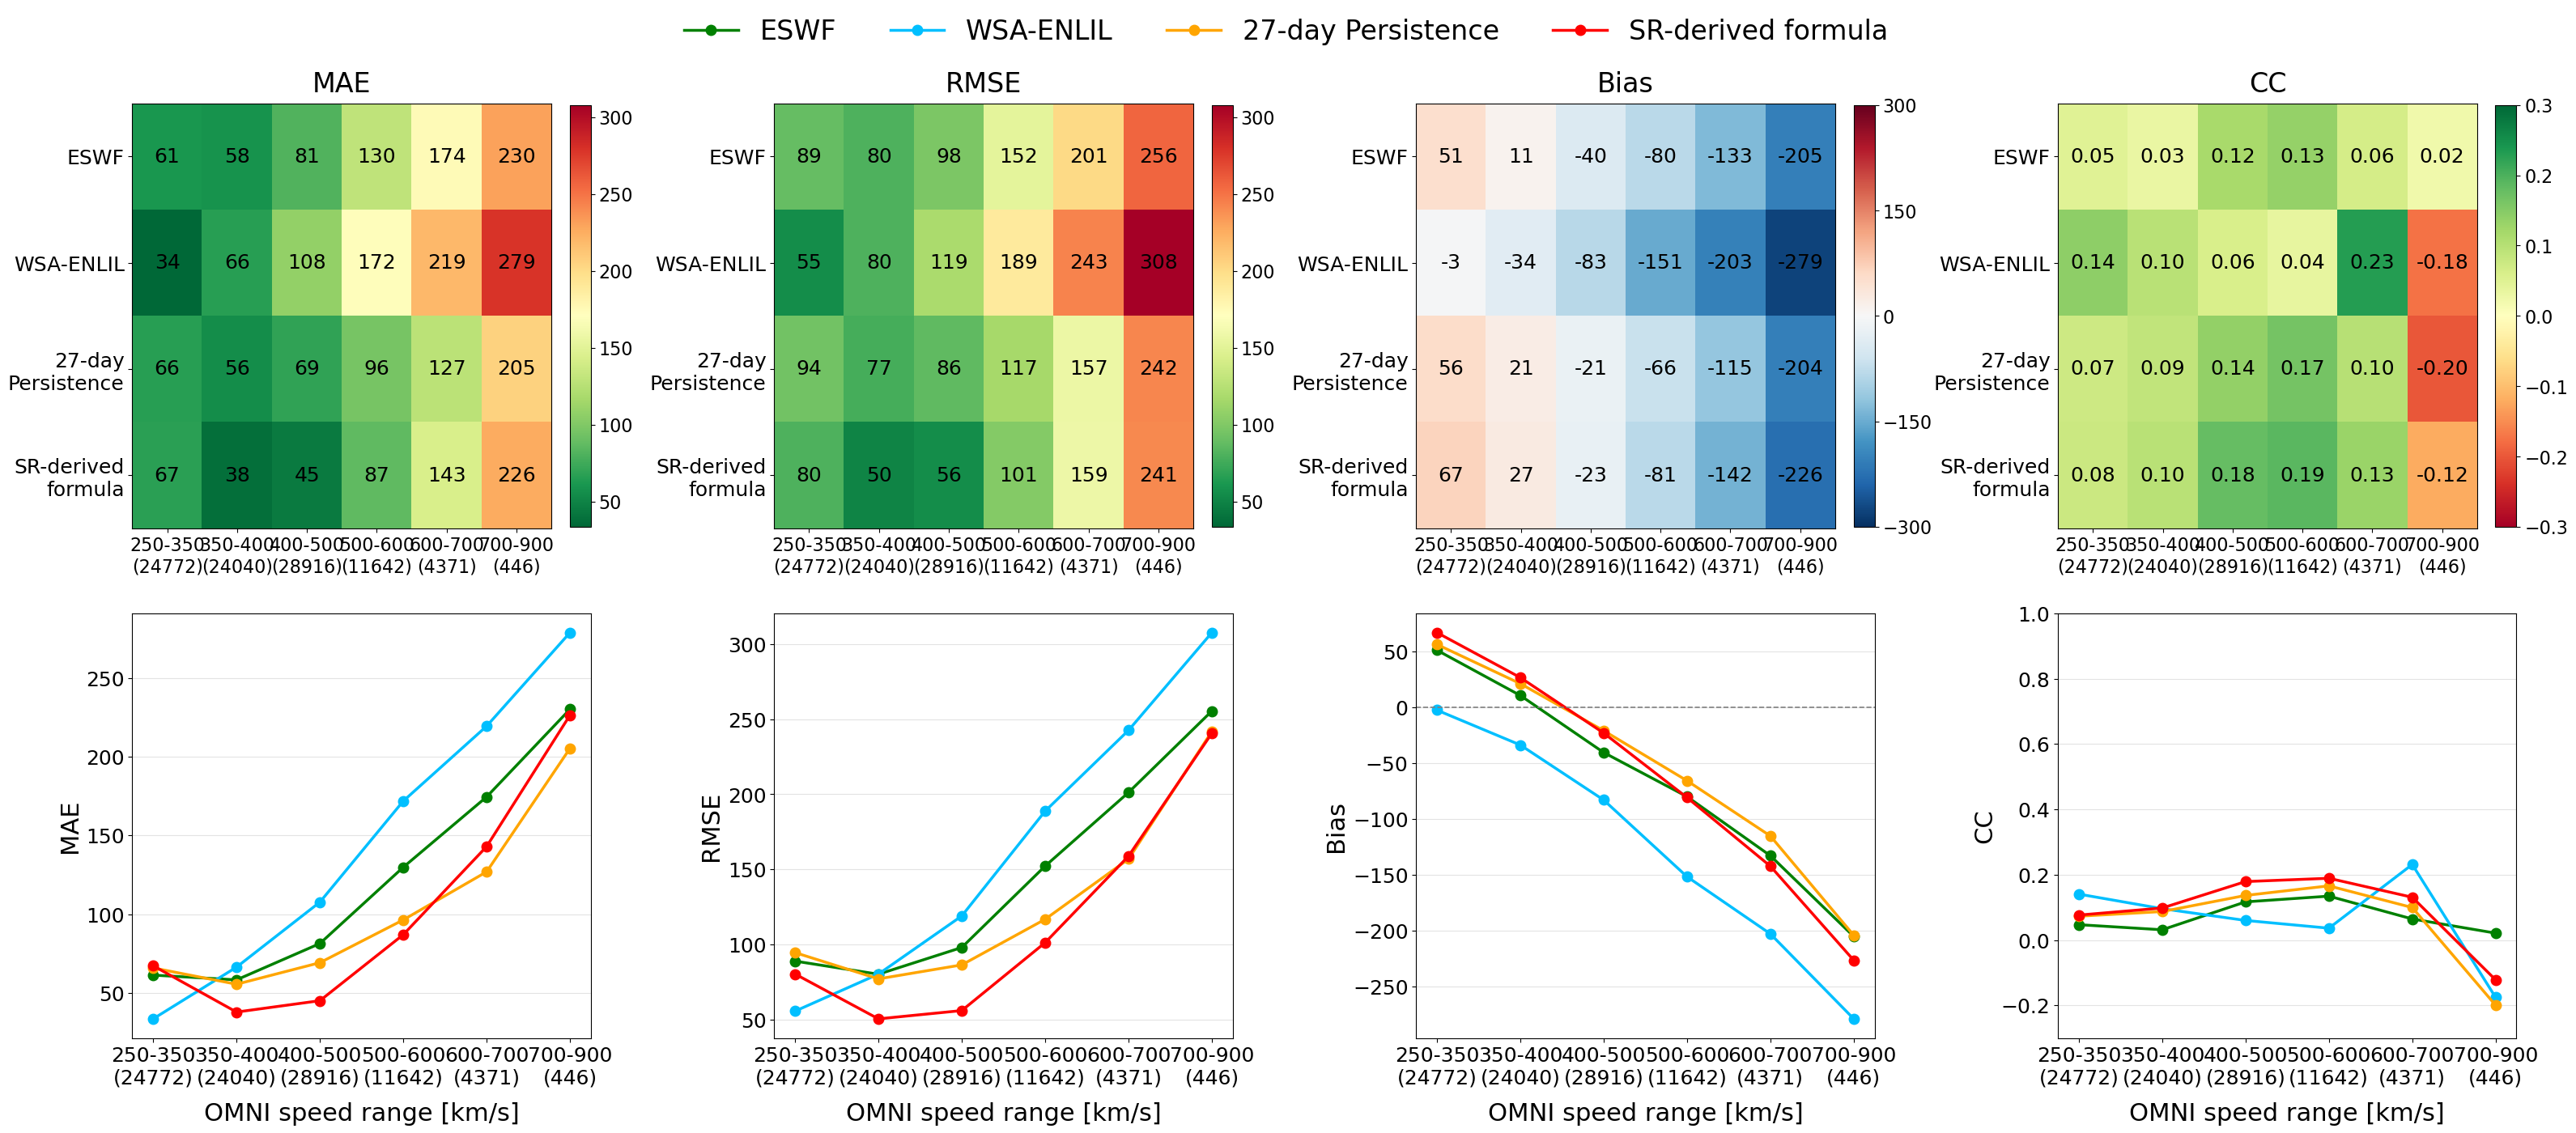

In [5]:
model_specs = [
    ("eswf2", "ESWF"),
    ("wsa_enlil", "WSA-ENLIL"),
    ("speed_p27", "Persistence (27 days)"),
    ("best_sr", "SR-derived formula"),
]
color_map = {"ESWF": "green", "WSA-ENLIL": "deepskyblue",
            "Persistence (27 days)": "orange", "SR-derived formula": "red"}
speed_bins = [250, 350, 400, 500, 600, 700, 900]

stats_dict, bin_labels = compute_binned_stats(df, model_specs, speed_bins, min_samples=10)

plot_binned_performance_heatmap(stats_dict, bin_labels, color_map, metrics=("MAE", "RMSE", "Bias", "CC"))
plt.show()